In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from wassa_functions import allen_reconstruction_comparison
from dataset_generation import kfold_dataset, make_allen_dataset
from wassa_plots import make_violin, plot_results
from wassa_metrics import WassDist
from wassa_training import get_training_parameters, learn_motifs
import matplotlib.pyplot as plt
import scipy, torch, glob
import numpy as np
from wassa import WassA
from tqdm.notebook import tqdm

In [3]:
dataset_name = 'allen_data_by_image'
device = 'cpu'
dataset_path = '../../'+dataset_name+'/*'
saving_path = '../results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

In [4]:
training_parameters_emd = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'emd',
    'activation' : 'conv',
    'sigmoid' : False,
    'zeros' : 'ignore',
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : ['factors_cc'],
    'lambda' : [.01],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : None,
    'normalize_input' : True,
}

In [5]:
training_parameters_mse = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : ['factors_cc'],
    'lambda' : [.001],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : None,
    'normalize_input' : True
}

In [6]:
training_parameters_frs = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [7]:

frs = False
training_parameters = training_parameters_emd

mse_loss = torch.nn.MSELoss(reduction='none')
emd_loss = WassDist(zeros='same',normalize=True, reduction = 'none')

all_trainsets, all_testsets, all_othersets = make_allen_dataset(dataset_path, device=device)
ind = torch.randint(len(all_trainsets),[1]).item()

if frs:
    training_set, testing_set, othersets = all_trainsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_testsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_othersets[ind].mean(dim=-1).unsqueeze(-1).to(device)
else:
    training_set, testing_set, othersets = all_trainsets[ind].to(device), all_testsets[ind].to(device), all_othersets[ind].to(device)

num_samples, num_neurons, num_timesteps = training_set.shape
training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
model = WassA(training_parameters,device=device)
model_name = saving_path+dataset_name+str(ind)+get_training_parameters(training_parameters)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None)
if training_parameters['normalize_input']:
    testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
factors_testing, testingset_hat = model(testing_set)
factors_others, otherset_hat = model(othersets)
mse_losses_id  = mse_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
emd_losses_id  = emd_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
mse_losses_ood  = mse_loss(otherset_hat,othersets).mean(axis=(1,2)).detach()
emd_losses_ood  = emd_loss(otherset_hat,othersets).mean(axis=(1,2)).detach()
print(mse_losses_id/mse_losses_ood, mse_losses_ood, emd_losses_id, emd_losses_ood)

  0%|          | 0/2000 [00:00<?, ?it/s]

tensor([0.1180, 0.1074]) tensor([0.0094, 0.0093]) tensor([0.2040, 0.2049]) tensor([0.2025, 0.2193])


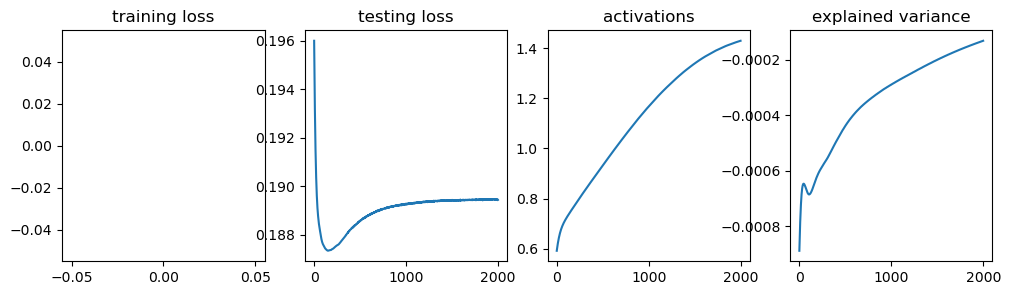

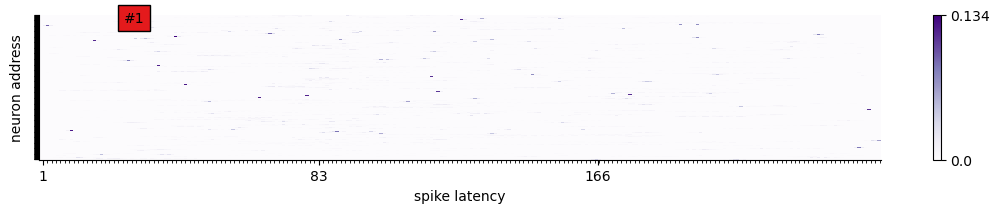

In [8]:
plot_results(training_metrics, metric_names, model, training_set[0], model=None, spike_times = None)

In [9]:
def compute_decoding_score(loss):
    score = 0
    for a in range(len(loss)):
        for i in range(loss[0].shape[1]):
            true_ind = i//2
            ind_hat = np.argmin(loss[a][:,i])
            if true_ind == ind_hat.item():
                score +=1
    return score

def classifier_multi(dataset_name, training_parameters, metric_names, frs=False, saving_path = 'results/allen_',device='cpu'):

    mse_loss = torch.nn.MSELoss(reduction='none')
    emd_loss = WassDist(zeros='same',normalize=True, reduction = 'none')

    dataset_path = '../../'+dataset_name+'/*'

    all_mse, all_emd = [], []
    all_trainsets, _, _ = make_allen_dataset(dataset_path, device=device)
    number_folds, number_animals, number_images, number_repetitions = 5, 32, 20, 10

    dec_score_emd, dec_score_mse = [], []
    fold = 0
    
    for k in range(1,5):
        all_testsets, labels = make_allen_testsets_for_decoding(dataset_path,fold_ind=fold,device=device)
    
        for ind_animal in tqdm(range(number_animals)):
    
            ind_images = labels[ind_animal]
    
            if frs:
                testing_set = all_testsets[ind_animal].mean(dim=-1).unsqueeze(-1)
            else:
                testing_set = all_testsets[ind_animal]
    
            mse_losses, emd_losses, corr = torch.zeros([20,40]), torch.zeros([20,40]), torch.zeros([20,40])
    
            num_samples, num_neurons, num_timesteps = testing_set.shape
            training_parameters['kernel_size'] = (k,num_neurons, num_timesteps)
            for image in range(number_images):
                ind_trainset = int(ind_animal*100+image*5+fold)
                if frs:
                    training_set = all_trainsets[ind_trainset].mean(dim=-1).unsqueeze(-1)
                else:
                    training_set = all_trainsets[ind_trainset]
                model = WassA(training_parameters,device=device)
                model_name = saving_path+dataset_name+str(ind_trainset)+get_training_parameters(training_parameters)
                model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None,verbose=False)
                
                if training_parameters['normalize_input']:
                    testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
                factors_testing, testingset_hat = model(testing_set)
            
                mse_losses[image]  = mse_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
                emd_losses[image]  = emd_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
    
            all_mse += [mse_losses]
            all_emd += [emd_losses]

        dec_score_emd.append(compute_decoding_score(all_emd[(k-1)*number_animals:k*number_animals])/(2*number_images*number_animals))
        dec_score_mse.append(compute_decoding_score(all_mse[(k-1)*number_animals:k*number_animals])/(2*number_images*number_animals))
        print(f'percentage correct for EMD decoding: {dec_score_emd[k-1]}')
        print(f'percentage correct for MSE decoding: {dec_score_mse[k-1]}')
    
    return all_mse, all_emd, dec_score_mse, dec_score_emd

In [10]:
def make_allen_testsets_for_decoding(dataset_path, number_samples_per_image=10, number_folds=5, fold_ind = 0, device='cpu'):
    
    files_list = glob.glob(dataset_path)
    number_animals = len(files_list)
    all_trainsets, all_testsets = [], []
    id_image_by_animal = []

    for f in range(len(files_list)):
        data = torch.load(files_list[f], weights_only = True)
        data = data.to(torch.float32).to(device)
        number_samples, number_neurons, number_timesteps = data.shape
        number_images = number_samples//number_samples_per_image
        id_image, testsets_animal = [], []
        for image in range(number_images):
            trainsets, testsets, indices = kfold_dataset(data[image*number_samples_per_image:(image+1)*number_samples_per_image],k=number_folds)
            testsets_animal += testsets[fold_ind].unsqueeze(0)
            id_image += [image]*testsets[fold_ind].shape[0]
        id_image_by_animal += [id_image]
        all_testsets += [torch.cat(testsets_animal)]
            
    return all_testsets, id_image_by_animal

In [11]:
all_mse, all_emd, dec_score_mse, dec_score_emd = classifier_multi(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
all_mse, all_emd, dec_score_mse, dec_score_emd = classifier_multi(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,device=device)

In [ ]:
all_mse, all_emd, dec_score_mse, dec_score_emd = classifier_multi(dataset_name,training_parameters_frs,metric_names,saving_path=saving_path,frs=True,device=device)